#Credit Risk Prediction and Explainable Credit Scoring System

Author: Megha Malhotra

#Objective

This project develops a machine learning based credit risk assessment framework to identify customers likely to become seriously delinquent within the next two years.
The solution follows an end-to-end analytics workflow commonly used by credit bureaus, banks, and risk analytics firms such as TransUnion.

#Business Problem

Financial institutions face significant losses due to loan defaults.
The key challenge is:
Can we identify high-risk customers before extending credit?

Early identification of risky borrowers enables:

Better lending decisions

Lower default rates

Improved risk-adjusted profitability

More accurate credit scoring

#Success Criteria

Develop a predictive model that:

Identifies customers likely to default

Achieves strong ROC-AUC performance

Provides interpretable business explanations

Supports future deployment into a credit risk workflow

#Import Dataset

Dataset: Give Me Some Credit
Target Variable:

SeriousDlqin2yrs

1 = Customer defaulted

0 = Customer did not default

In [1]:
!gdown 1ix-ezN3RLNmaWFf1zhIuPZhBSsLkzDAq

Downloading...
From: https://drive.google.com/uc?id=1ix-ezN3RLNmaWFf1zhIuPZhBSsLkzDAq
To: /content/cs-training.csv
100% 7.56M/7.56M [00:00<00:00, 14.2MB/s]


In [2]:
import pandas as pd

df=pd.read_csv('cs-training.csv')
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


#Import Libraries

The project uses:

•	Pandas for data manipulation

•	NumPy for numerical calculations

•	Matplotlib and Seaborn for visualisation

•	Scikit-Learn for machine learning

•	XGBoost for advanced risk modelling

•	SHAP for explainable AI

In [3]:
!pip install xgboost shap -q

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

#Data Understanding

Before modelling, it is important to understand

*   Dataset dimensions
*   Data types
*   Missing Values
*   Variable distributions








In [5]:
df.shape

(150000, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [7]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


#Initial Observations

Document findings here after reviewing outputs.
Example:

*   Dataset contains approximately 150k customers.
*   Several variables contain missing values.
*   Significant variations exist acrosss financial metrics.
*   Default appears to be minority class.







#Data Quality Assessment

Missing values can negatively impact model performance and must be addressed before training

In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [9]:
missing=(df.isnull().sum().sort_values(ascending=False))

#Exploratory Data Analysis

The goal of EDA is to understand:

-Customer behaviour

-Relationship between variables

-Potential risk indicators

In [10]:
df['SeriousDlqin2yrs'].value_counts()

,count
SeriousDlqin2yrs,
0,139974
1,10026


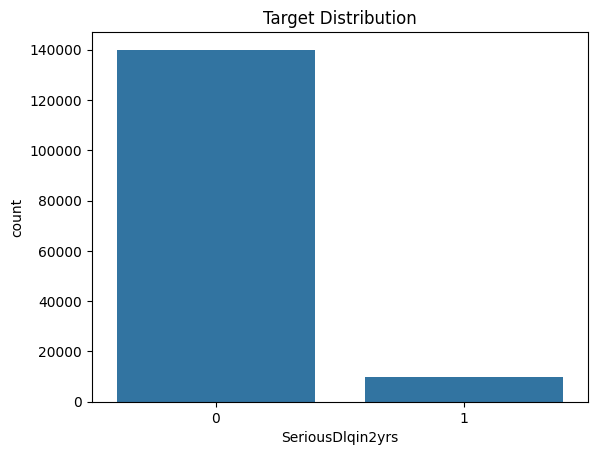

In [11]:
sns.countplot(x='SeriousDlqin2yrs',data=df)

plt.title("Target Distribution")
plt.show()

## Business Interpretation: Class Imbalance

The dataset contains approximately:

- Non-default customers: 139,974
- Default customers: 10,026

This means only around 6.7% of borrowers defaulted.

### Why This Matters

Class imbalance is common in lending data.

If a model predicts every customer as non-default, it would still achieve high accuracy but provide little business value.

For this reason, ROC-AUC is selected as the primary evaluation metric instead of accuracy.

### Business Impact

The objective is not simply to maximize accuracy but to correctly identify risky borrowers before credit is approved.


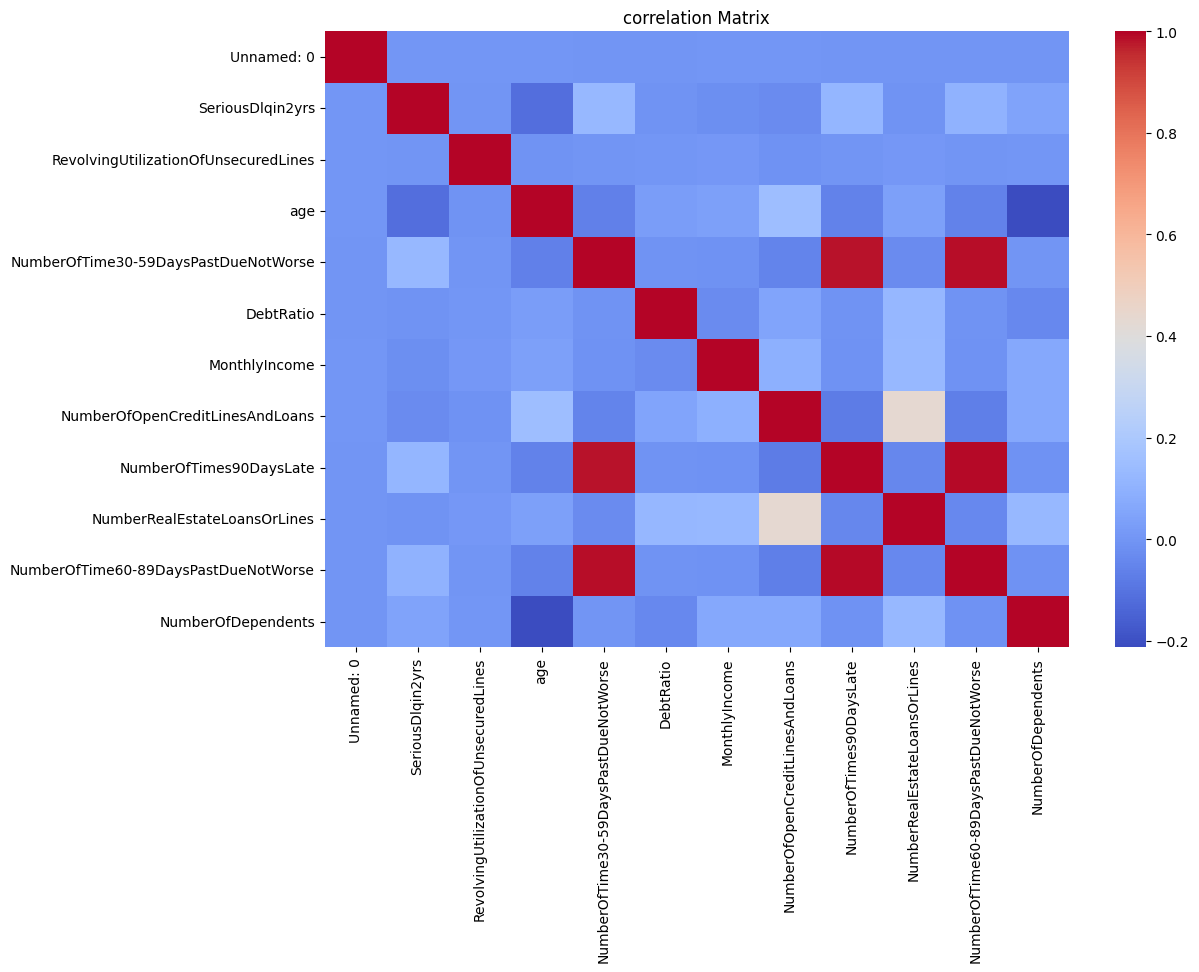

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("correlation Matrix")
plt.show()

## Correlation Analysis

Key observations:

- Delinquency variables exhibit positive correlation with default behaviour.
- Several late-payment indicators appear closely related and may contain overlapping information.
- No severe multicollinearity issues are immediately visible.

### Business Interpretation

Past payment behaviour is often one of the strongest predictors of future default.

This finding supports the hypothesis that customers with repeated payment delays present elevated credit risk.


# Outlier Analysis

Financial datasets frequently contain extreme observations.

Identifying unusual values is important because they can distort model performance and statistical summaries.

Examples observed include:

- Extremely high Debt Ratios
- Extremely high Income values
- Unusually high Credit Utilisation values

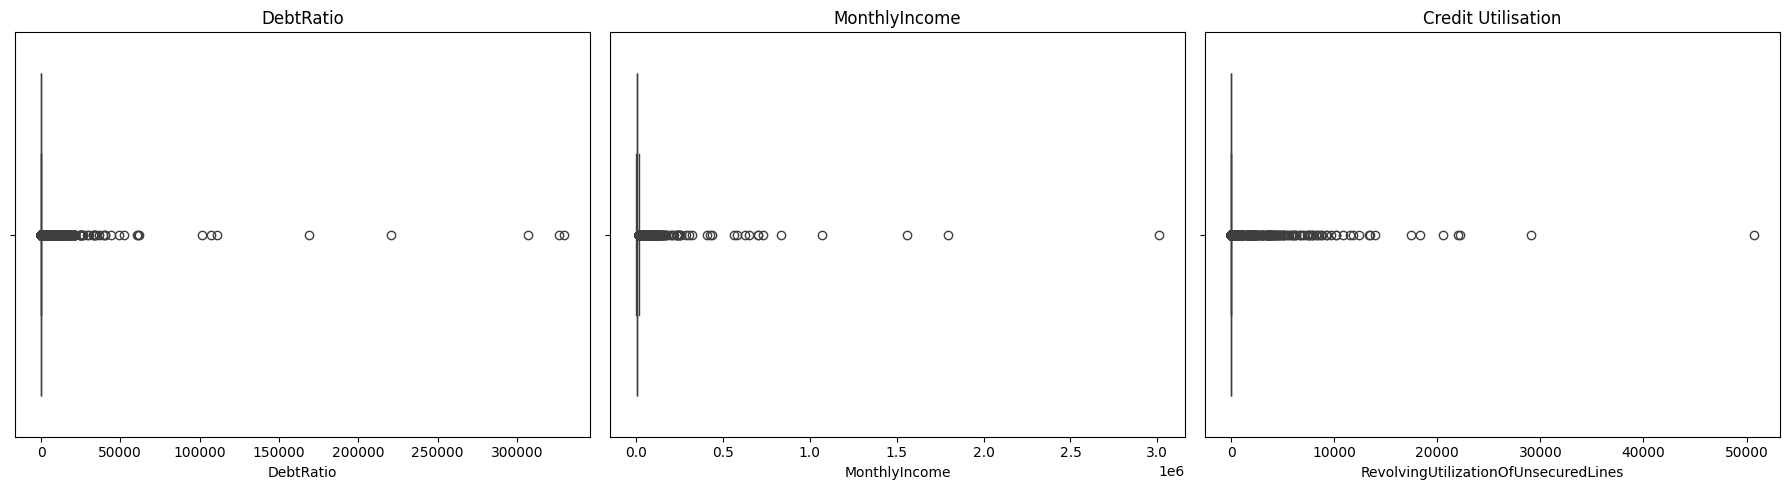

In [13]:
fig, ax = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(x=df["DebtRatio"], ax=ax[0])
ax[0].set_title("DebtRatio")

sns.boxplot(x=df["MonthlyIncome"], ax=ax[1])
ax[1].set_title("MonthlyIncome")

sns.boxplot(
    x=df["RevolvingUtilizationOfUnsecuredLines"],
    ax=ax[2]
)
ax[2].set_title("Credit Utilisation")

plt.tight_layout()
plt.show()

## Outlier Findings

Several variables contain extreme values.

Rather than removing these records, they are retained because unusual financial behaviour may itself be a signal of elevated credit risk.

Future model iterations may evaluate capping or winsorization techniques.

#Data Cleaning

Missing values will be imputed using median values.

The median is preferred because financial dataoften contains outliers.

In [14]:
df.drop(df.columns[0],axis=1,inplace=True)

In [15]:
df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(),
                           inplace=True)

df["NumberOfDependents"].fillna(df["NumberOfDependents"].median(),inplace=True)

In [16]:
df.isnull().sum()

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


#Feature Engineering

Feature engineering creates additional business-relevant variables that may imrove predition performance.

In [17]:
df["MonthlyDebt"]=(df["DebtRatio"]*df["MonthlyIncome"])

In [18]:
df["IncomePerDependent"]=(df["MonthlyIncome"]/(df["NumberOfDependents"]+1))

In [19]:
df["LatePayementScore"]=(
    df["NumberOfTime30-59DaysPastDueNotWorse"]
    +df["NumberOfTimes90DaysLate"]
    +df["NumberOfTime60-89DaysPastDueNotWorse"]
)

In [20]:
df["TotalPastDueEvents"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"]
    + df["NumberOfTime60-89DaysPastDueNotWorse"]
    + df["NumberOfTimes90DaysLate"]
)

### Total Past Due Events

This feature captures the cumulative number of delinquency incidents across all severity levels.

Business logic suggests that repeated delinquency behaviour increases future default risk.

#Business Rationale

Late payment history is one of the stroingest indicatos of future delinquency.

The engineered LatePaymentScore captures cumulative payment behaviour.

#Data Preparation

Prepare training and testing datasets

In [21]:
X=df.drop("SeriousDlqin2yrs",
          axis=1)

y=df["SeriousDlqin2yrs"]



In [22]:
X_train, X_test, y_train, y_test= train_test_split( X,y,
                                                   test_size=0.2, random_state=42, stratify=y)

In [23]:
scaler=StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)

X_test_scaled=scaler.transform(X_test)

## Data Splitting Strategy

The dataset was divided into:

- 80% Training Data
- 20% Testing Data

Stratified sampling was used to preserve the default rate across both datasets.

This approach ensures a realistic evaluation of model performance.

#Baseline Model: Logistic Regression

Logistic Regression is widely used in credit scoring because:

-Easy to explain

-Regulation-friendly

-Fast to Deploy

In [24]:
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)



LogisticRegression(max_iter=1000)

In [25]:
lr_pred= lr.predict(X_test_scaled)

lr_prob=lr.predict_proba(X_test_scaled)[:1]



In [26]:
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
print(roc_auc_score(y_test,lr_prob))

print(classification_report(y_test,lr_pred))

0.7155679830607443
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.57      0.04      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.75      0.52      0.52     30000
weighted avg       0.91      0.93      0.91     30000



## Logistic Regression Interpretation

ROC-AUC: 0.716

The model demonstrates moderate predictive capability.

Advantages:

- Highly interpretable
- Regulatory friendly
- Commonly used in traditional credit scorecards

Limitations:

- May struggle to capture nonlinear risk patterns
- Lower predictive power than ensemble methods

#Random Forest

Random Forest captures complex interactions between variables.

In [27]:
rf= RandomForestClassifier(n_estimators=300, random_state=42)

rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [28]:
rf_prob=rf.predict_proba(X_test)[:1]

In [29]:
rf_prob=rf.predict_proba(X_test)[:,1]
print(roc_auc_score(y_test,rf_prob))

0.848966510318239


## Random Forest Interpretation

ROC-AUC improved substantially compared with Logistic Regression.

This indicates that nonlinear relationships and feature interactions play an important role in predicting borrower risk.

Random Forest provides stronger prediction performance while retaining some interpretability through feature importance analysis.

#XGBoost

XGBoost is a leading algorithm in credit risk compeitions and real-world risk modelling.

In [30]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,random_State=42)

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [31]:
xgb_prob=xgb.predict_proba(X_test)[:,1]


In [32]:
print(roc_auc_score(y_test,xgb_prob))

0.869197376268206


## XGBoost Interpretation

ROC-AUC = 0.869

ROC-AUC measures the model's ability to distinguish between default and non-default borrowers.

Reference:

- 0.50 = Random Guessing
- 0.70 = Acceptable
- 0.80 = Strong
- Above 0.85 = Excellent

The result indicates strong discriminatory power and suggests that XGBoost is the preferred model for deployment.

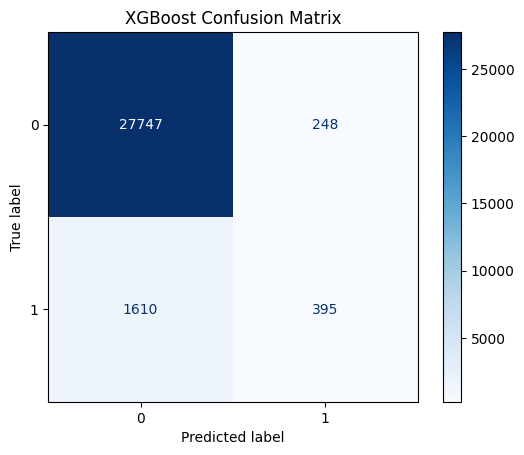

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix helps evaluate:

- True Positives
- True Negatives
- False Positives
- False Negatives

From a lending perspective, False Negatives are generally more costly.

A False Negative occurs when a risky borrower is incorrectly classified as low risk and receives credit approval.

#Model Comparison

Compare all candidate models.

In [34]:
results=pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC_AUC":[
        roc_auc_score(y_test,lr_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,xgb_prob)

    ]
})

results.sort_values(by="ROC_AUC", ascending=False)


,Model,ROC_AUC
2,XGBoost,0.869197
1,Random Forest,0.848967
0,Logistic Regression,0.715568


# Model Selection Rationale

Model comparison indicates that XGBoost achieved the highest predictive performance.

Although Logistic Regression offers superior transparency, XGBoost provides substantially stronger risk discrimination.

To balance accuracy and explainability, SHAP analysis was incorporated.

This combination is commonly used in modern credit risk analytics.

#Feature Importance

Identify the key drivers of customer default

In [35]:
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":xgb.feature_importances_
})

importance=importance.sort_values(by="Importance",
                                  ascending=False)

importance.head(10)

,Feature,Importance
12,LatePayementScore,0.678622
6,NumberOfTimes90DaysLate,0.084152
0,RevolvingUtilizationOfUnsecuredLines,0.080066
2,NumberOfTime30-59DaysPastDueNotWorse,0.027713
7,NumberRealEstateLoansOrLines,0.023319
8,NumberOfTime60-89DaysPastDueNotWorse,0.019301
1,age,0.014437
3,DebtRatio,0.013995
5,NumberOfOpenCreditLinesAndLoans,0.012596
4,MonthlyIncome,0.012099


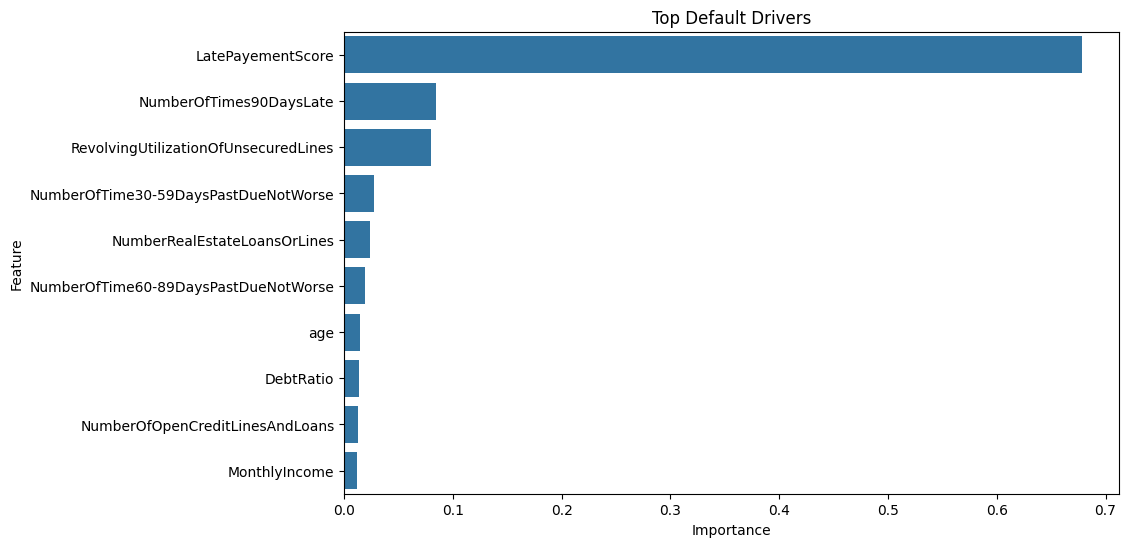

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(data=importance.head(10),
                     x="Importance",
                     y="Feature"
)

plt.title("Top Default Drivers")

plt.show()

## Business Interpretation of Default Drivers

Top risk indicators include:

- LatePaymentScore
- NumberOfTimes90DaysLate
- Credit Utilisation
- Debt Ratio

These findings align with established credit risk theory.

Customers demonstrating repeated delinquency behaviour exhibit significantly higher default probability.

#Explainable AI (SHAP)

Financial institutions require explainable models.

SHAP helps understand:

-Why a prediction was made
-Which variables influence risk
-Model transperancy


In [37]:
import shap

explainer=shap.TreeExplainer(xgb)

shap_values=explainer.shap_values(X_test)

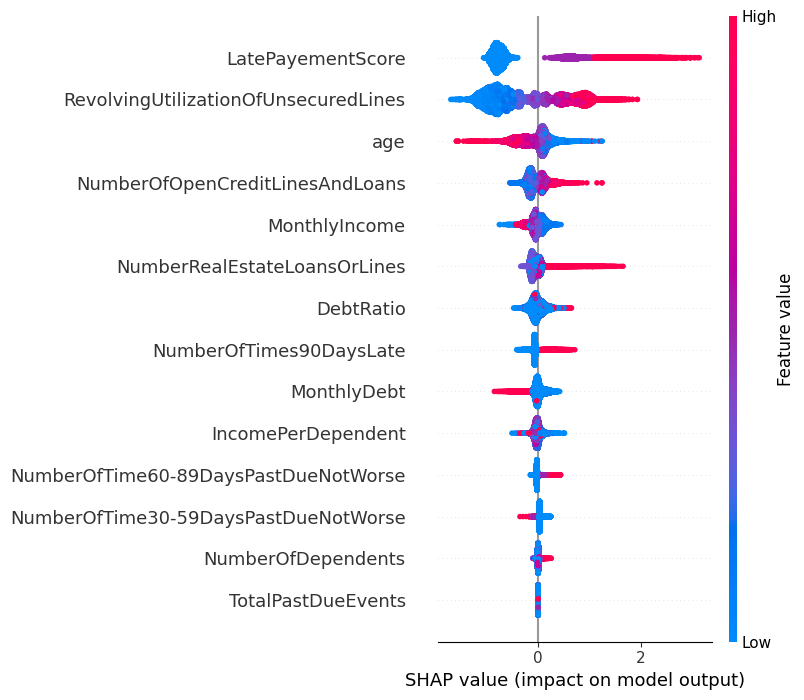

In [38]:
shap.summary_plot(shap_values,X_test)

## Explainability Insights

SHAP values explain how individual variables influence model predictions.

Key observations:

- Higher delinquency metrics increase default risk.
- Higher credit utilisation increases default risk.
- Certain income and debt characteristics contribute to elevated borrower risk.

These explanations improve model transparency and support analyst decision-making.

# Business Risk Assessment

In credit risk modelling, prediction errors have different costs.

### False Positive

A creditworthy borrower is rejected.

Potential impact:

- Lost revenue
- Reduced customer acquisition
- Competitive disadvantage

### False Negative

A risky borrower is approved.

Potential impact:

- Loan losses
- Increased default rates
- Higher capital provisioning requirements

For most lenders, False Negatives represent the greater business risk.

# Executive Summary

## Objective

Develop a predictive framework to identify customers likely to become seriously delinquent within two years.

## Best Performing Model

XGBoost

ROC-AUC: 0.869

## Key Findings

- Historical delinquency is the strongest predictor of future default.
- Credit utilisation significantly influences borrower risk.
- Debt-related characteristics contribute to elevated default probability.
- Engineered behavioural risk features improved predictive performance.

## Business Recommendations

1. Deploy XGBoost as the primary risk-screening model.
2. Introduce automated alerts for customers with repeated delinquency events.
3. Integrate SHAP explanations into analyst review workflows.
4. Continuously monitor model performance and recalibrate quarterly.



## Business Value

The proposed solution enables proactive identification of high-risk borrowers, improved lending decisions, and enhanced portfolio risk management.